In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
from matplotlib.gridspec import GridSpec

## Define colourblind acessible colour palette
colour_palette = ['#FFB000','#648FFF','#785EF0',
                  '#DC267F','#FE6100','#3D1EB2',
                  '#894D80','#16AA02','#B5592B',
                  '#A3C1ED']

# 一.資料載入和合併

In [5]:
excel_file_path3 = 'C:/Users/weisz/OneDrive/Documents/中信兄弟/程式碼/WOBA/woba權重.xlsx'
#C:\Users\weisz\OneDrive\Documents\中信兄弟\程式碼\WOBA
#excel_file_path5 = 'C:/Users/weisz/OneDrive/Documents/中信兄弟/Trackman/new/2022_trackman.xlsx'
excel_file_path6 = 'C:/Users/weisz/OneDrive/Documents/中信兄弟/Season_data/2023_non_trackman.xlsx'
excel_file_path8 = 'C:/Users/weisz/OneDrive/Documents/中信兄弟/Season_data/2024_non_trackman.xlsx'
excel_file_path9 = 'C:/Users/weisz/OneDrive/Documents/中信兄弟/Season_data/2025_non_trackman.xlsx'
excel_file_path10 = 'C:/Users/weisz/OneDrive/Documents/中信兄弟/Season_data/2026_non_trackman.xlsx'
sheet_name = 'Sheet1'

In [6]:
RE = pd.read_excel(excel_file_path3, sheet_name=sheet_name, engine='calamine')
#track_2022 = pd.read_excel(excel_file_path5, sheet_name=sheet_name)
#track_2023_1 = pd.read_excel(excel_file_path6, sheet_name=sheet_name)
track_2023 = pd.read_excel(excel_file_path6, sheet_name=sheet_name, engine='calamine')
track_2024 = pd.read_excel(excel_file_path8, sheet_name=sheet_name, engine='calamine')
track_2025 = pd.read_excel(excel_file_path9, sheet_name=sheet_name, engine='calamine')
track_2026 = pd.read_excel(excel_file_path10, sheet_name=sheet_name, engine='calamine')

In [7]:
col=['bName','bHand','bTeamId','Stadium','PlayResult','RunsScored','ExitSpeed','Angle','Distance','GameID','TaggedHitType','KorBB','BatterId','PitchCall','TaggedPitchType','pType','result','zone25']

In [8]:
#track_2021= track_2021[col]
#track_2022= track_2022[col]
#track_2023_1= track_2023_1[col]
track_2023= track_2023[col]
track_2024=track_2024[col]
track_2025=track_2025[col]
track_2026=track_2026[col]

In [9]:
data = pd.concat([track_2026,track_2025, track_2024, track_2023], ignore_index=True)

data = data.dropna(subset=['GameID'])

In [10]:
data = data.dropna(subset=['result'])

In [11]:
data

,bName,bHand,bTeamId,Stadium,PlayResult,RunsScored,ExitSpeed,Angle,Distance,GameID,TaggedHitType,KorBB,BatterId,PitchCall,TaggedPitchType,pType,result,zone25
4,曾子祐,R,6569a9ddaf62a48d3f94b422,Douliu,Out,0.0,71.97452,-32.901406,6.09594,20260708-Douliu-1,GroundBall,Undefined,1.000191e+09,InPlay,Fastball,FF,GO,8
10,王博玄,L,6569a9ddaf62a48d3f94b422,Douliu,Undefined,0.0,NaN,NaN,NaN,20260708-Douliu-1,Undefined,Strikeout,1.000191e+09,StrikeCalled,Fastball,FF,SO,16
13,吳念庭,L,6569a9ddaf62a48d3f94b422,Douliu,Out,0.0,81.19549,61.632383,152.99296,20260708-Douliu-1,FlyBall,Undefined,2.132513e+07,InPlay,Fastball,FF,FO,9
16,郭天信,L,65630ee95559b6d7a6d5d201,Douliu,Out,0.0,91.35278,-20.035785,7.42763,20260708-Douliu-1,GroundBall,Undefined,1.000075e+09,InPlay,Fastball,FF,GO,12
18,劉基鴻,R,65630ee95559b6d7a6d5d201,Douliu,Single,0.0,103.66826,3.319192,110.59489,20260708-Douliu-1,GroundBall,Undefined,1.000075e+09,InPlay,Fastball,FF,1B,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
352676,成晉,R,65630eed5559b6d7a6d5d202,Brothers,Sacrifice,1.0,83.88111,44.657549,271.82560,20231021-Brothers-1,FlyBall,Undefined,1.000029e+09,InPlay,Slider,SL,SF,18
352677,梁家榮,L,65630eed5559b6d7a6d5d202,Brothers,Out,0.0,76.40598,88.124795,NaN,20231021-Brothers-1,Popup,Undefined,1.000029e+09,InPlay,Sinker,SI,FO,13
352680,詹子賢,R,65630ee55559b6d7a6d5d200,Brothers,Out,0.0,98.15558,23.893887,375.41479,20231021-Brothers-1,FlyBall,Undefined,1.000029e+09,InPlay,Fastball,FF,FO,9
352684,陳子豪,L,65630ee55559b6d7a6d5d200,Brothers,Undefined,0.0,NaN,NaN,NaN,20231021-Brothers-1,Undefined,Strikeout,1.000029e+09,StrikeCalled,Cutter,FC,SO,17


# 二.資料預處理

## 1.切出年份

In [12]:
data.loc[:, '時間'] = data['GameID'].str[:8]
data.loc[:, 'Year'] = data['時間'].str[:4]
#data.loc[:, 'Month'] = data['GameID'].str[5:7]
data.loc[:, '日期'] = data['GameID'].str[:8]

In [13]:
year_items = data['Year'].unique()
year_items

array(['2026', '2025', '2024', '2023'], dtype=object)

In [14]:
name_mapping = {
    '65630ee55559b6d7a6d5d200':'Brothers',
    '65630ee95559b6d7a6d5d201':'Dragons', 
    '65630eed5559b6d7a6d5d202':'Monkeys', 
    '65630ef25559b6d7a6d5d203':'Lions',
    '65630ef65559b6d7a6d5d204':'Guardians',
    '6569a9ddaf62a48d3f94b422':'Hawks',
    }

# 新增一列"球員"，根据"Pitcher"列的值匹配中文名
data ['bTeam'] = data ['bTeamId'].map(name_mapping)
data

,bName,bHand,bTeamId,Stadium,PlayResult,RunsScored,ExitSpeed,Angle,Distance,GameID,...,BatterId,PitchCall,TaggedPitchType,pType,result,zone25,時間,Year,日期,bTeam
4,曾子祐,R,6569a9ddaf62a48d3f94b422,Douliu,Out,0.0,71.97452,-32.901406,6.09594,20260708-Douliu-1,...,1.000191e+09,InPlay,Fastball,FF,GO,8,20260708,2026,20260708,Hawks
10,王博玄,L,6569a9ddaf62a48d3f94b422,Douliu,Undefined,0.0,NaN,NaN,NaN,20260708-Douliu-1,...,1.000191e+09,StrikeCalled,Fastball,FF,SO,16,20260708,2026,20260708,Hawks
13,吳念庭,L,6569a9ddaf62a48d3f94b422,Douliu,Out,0.0,81.19549,61.632383,152.99296,20260708-Douliu-1,...,2.132513e+07,InPlay,Fastball,FF,FO,9,20260708,2026,20260708,Hawks
16,郭天信,L,65630ee95559b6d7a6d5d201,Douliu,Out,0.0,91.35278,-20.035785,7.42763,20260708-Douliu-1,...,1.000075e+09,InPlay,Fastball,FF,GO,12,20260708,2026,20260708,Dragons
18,劉基鴻,R,65630ee95559b6d7a6d5d201,Douliu,Single,0.0,103.66826,3.319192,110.59489,20260708-Douliu-1,...,1.000075e+09,InPlay,Fastball,FF,1B,14,20260708,2026,20260708,Dragons
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
352676,成晉,R,65630eed5559b6d7a6d5d202,Brothers,Sacrifice,1.0,83.88111,44.657549,271.82560,20231021-Brothers-1,...,1.000029e+09,InPlay,Slider,SL,SF,18,20231021,2023,20231021,Monkeys
352677,梁家榮,L,65630eed5559b6d7a6d5d202,Brothers,Out,0.0,76.40598,88.124795,NaN,20231021-Brothers-1,...,1.000029e+09,InPlay,Sinker,SI,FO,13,20231021,2023,20231021,Monkeys
352680,詹子賢,R,65630ee55559b6d7a6d5d200,Brothers,Out,0.0,98.15558,23.893887,375.41479,20231021-Brothers-1,...,1.000029e+09,InPlay,Fastball,FF,FO,9,20231021,2023,20231021,Brothers
352684,陳子豪,L,65630ee55559b6d7a6d5d200,Brothers,Undefined,0.0,NaN,NaN,NaN,20231021-Brothers-1,...,1.000029e+09,StrikeCalled,Cutter,FC,SO,17,20231021,2023,20231021,Brothers


In [15]:
name_mapping2 = {
    'Brothers':'台中', 
    'Guardians':'新莊', 
    'Douliu':'斗六', 
    'FargloryDome':'大巨蛋', 
    'TianMUStadium':'天母',
    'BrothersMinor':'屏東',
    'ChengchingLakeStadium':'澄清湖',
    'TainanInternational':'亞太主',
    'TaoyuanStadium':'桃園'
}
name_mapping3 = {
    'Brothers':'Outdoor', 
    'Guardians':'Outdoor', 
    'Douliu':'Outdoor', 
    'FargloryDome':'Dome', 
    'TianMUStadium':'Outdoor',
    'BrothersMinor':'Outdoor',
    'ChengchingLakeStadium':'Outdoor',
    'TainanInternational':'Outdoor',
    'TaoyuanStadium':'Outdoor'
}

data['球場'] = data['Stadium'].map(name_mapping2)
data['室內外'] = data['Stadium'].map(name_mapping3)

In [16]:
name_mapping = {
    'Fastball':'直球', 
    'ChangeUp':'變速球', 
    'Cutter':'卡特球', 
    'Curveball':'曲球', 
    'Splitter':'指叉球',
    'Slider':'滑球', 
    'Sinker':'伸卡球',
    'KnuckleBall':'彈指曲球', 
    'TwoSeamFastBall':'伸卡球', 
    'FourSeamFastBall':'直球', 
    'OneSeamFastBall':'伸卡球',
    'Changeup':'變速球', 
    'Knuckleball':'彈指曲球'  
}

# 新增一列"球員"，根据"Pitcher"列的值匹配中文名
mask = data['Year'].isin(['2021', '2022'])
data.loc[mask, '球種'] = data.loc[mask, 'TaggedPitchType'].map(name_mapping)

In [17]:
name_mapping = {
    'FF':'直球', 
    'CH':'變速球', 
    'FC':'卡特球', 
    'CU':'曲球', 
    'FO':'指叉球',
    'SL':'滑球', 
    'SI':'伸卡球',
    'KN':'彈指曲球',
    'SW':'Sweeper'
}

# 新增一列"球員"，根据"Pitcher"列的值匹配中文名
mask = data['Year'].isin(['2023', '2024','2025','2026'])
data.loc[mask, '球種'] = data.loc[mask, 'pType'].map(name_mapping)

## 2.擊球初速轉正數

In [18]:
data['ExitSpeed'] = data['ExitSpeed'].abs()
#data['Distance'] = data['Distance'].abs()

In [19]:
data

,bName,bHand,bTeamId,Stadium,PlayResult,RunsScored,ExitSpeed,Angle,Distance,GameID,...,pType,result,zone25,時間,Year,日期,bTeam,球場,室內外,球種
4,曾子祐,R,6569a9ddaf62a48d3f94b422,Douliu,Out,0.0,71.97452,-32.901406,6.09594,20260708-Douliu-1,...,FF,GO,8,20260708,2026,20260708,Hawks,斗六,Outdoor,直球
10,王博玄,L,6569a9ddaf62a48d3f94b422,Douliu,Undefined,0.0,NaN,NaN,NaN,20260708-Douliu-1,...,FF,SO,16,20260708,2026,20260708,Hawks,斗六,Outdoor,直球
13,吳念庭,L,6569a9ddaf62a48d3f94b422,Douliu,Out,0.0,81.19549,61.632383,152.99296,20260708-Douliu-1,...,FF,FO,9,20260708,2026,20260708,Hawks,斗六,Outdoor,直球
16,郭天信,L,65630ee95559b6d7a6d5d201,Douliu,Out,0.0,91.35278,-20.035785,7.42763,20260708-Douliu-1,...,FF,GO,12,20260708,2026,20260708,Dragons,斗六,Outdoor,直球
18,劉基鴻,R,65630ee95559b6d7a6d5d201,Douliu,Single,0.0,103.66826,3.319192,110.59489,20260708-Douliu-1,...,FF,1B,14,20260708,2026,20260708,Dragons,斗六,Outdoor,直球
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
352676,成晉,R,65630eed5559b6d7a6d5d202,Brothers,Sacrifice,1.0,83.88111,44.657549,271.82560,20231021-Brothers-1,...,SL,SF,18,20231021,2023,20231021,Monkeys,台中,Outdoor,滑球
352677,梁家榮,L,65630eed5559b6d7a6d5d202,Brothers,Out,0.0,76.40598,88.124795,NaN,20231021-Brothers-1,...,SI,FO,13,20231021,2023,20231021,Monkeys,台中,Outdoor,伸卡球
352680,詹子賢,R,65630ee55559b6d7a6d5d200,Brothers,Out,0.0,98.15558,23.893887,375.41479,20231021-Brothers-1,...,FF,FO,9,20231021,2023,20231021,Brothers,台中,Outdoor,直球
352684,陳子豪,L,65630ee55559b6d7a6d5d200,Brothers,Undefined,0.0,NaN,NaN,NaN,20231021-Brothers-1,...,FC,SO,17,20231021,2023,20231021,Brothers,台中,Outdoor,卡特球


## 3.將"KorBB"資料填入'PlayResult'和'TaggedHitType'

In [20]:
KorBB_items = data['KorBB'].unique()
KorBB_items

array(['Undefined', 'Strikeout', 'Walk'], dtype=object)

In [21]:
data.loc[data['KorBB'].isin(['Walk']), 'PlayResult'] = data['KorBB']
data.loc[data['KorBB'].isin(['Strikeout']), 'PlayResult'] = data['KorBB']
data.loc[data['PitchCall'].isin(['HitByPitch']), 'PlayResult'] = data['PitchCall']

## 4.空值填入
### 依據各打擊結果之平均擊球初速,仰角和距離補充缺失值

In [22]:
#mean_values = data.groupby('PlayResult')[['ExitSpeed', 'Angle', 'Distance']].transform('mean')

#data['ExitSpeed'] = data['ExitSpeed'].replace(0, np.nan)
#data['Angle'] = data['Angle'].replace(0, np.nan)
#data['Distance'] = data['Distance'].replace(0, np.nan)

# 使用 transform 和 fillna 方法填補空值
#data['ExitSpeed'] = data['ExitSpeed'].fillna(data.groupby('PlayResult')['ExitSpeed'].transform('mean'))
#data['Angle'] = data['Angle'].fillna(data.groupby('PlayResult')['Angle'].transform('mean'))
#data['Distance'] = data['Distance'].fillna(data.groupby('PlayResult')['Distance'].transform('mean'))

In [23]:
playresult_items = data['result'].unique()
playresult_items

array(['GO', 'SO', 'FO', '1B', 'GIDP', 'uBB', 'FC', 'E', '3B', '2B', 'SH',
       'SF', 'HBP', 'IGNORE', 'HR', 'DP', 'IHR', 'D3S', 'ID', 'IH', 'IBB'],
      dtype=object)

## 5.移除不需要的資料 
#### 1.'TaggedHitType'裡的'Undefined':可能為界外球...等等
#### 2.'PlayResult'裡的'Error','FoulBall','StolenBase','CaughtStealing','FieldersChoice'

In [24]:
result_to_remove = ['Undefined','IGNORE']
data = data[~data['result'].isin(result_to_remove)]

In [25]:
#result_to_remove = ['E','FoulBall','StolenBase','CaughtStealing','FC']
#data = data[~data['result'].isin(result_to_remove)]

## 6.計算woba 

In [26]:
conditions_tb = [(data['result']=='1B'),
                 (data['result']=='2B'),
                 (data['result']=='3B'),
                 (data['result']=='HR')]

choices_tb = [1,
              2,
              3,
              4]

## Assign Total Base Value to batted ball events. 0 for all field outs
data['tb'] = np.select(conditions_tb, choices_tb, default=0)


C:\Users\weisz\AppData\Local\Temp\ipykernel_16032\1170426187.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['tb'] = np.select(conditions_tb, choices_tb, default=0)


In [27]:
RE = pd.DataFrame(RE)

# 2. 使用 merge 將 RE24 數值併入原本的 data
# how='left' 代表保留所有原本 data 的資料
data = data.merge(RE, on='result', how='left')

# 3. 如果有沒對照到的 (NaN)，可以補 0
data = data.rename(columns={'RE24': 'woba'})

In [28]:
#刪除空值 tb和 woba為0的錯誤資料 (利用其他欄位篩選並刪除)
#data.dropna(subset=['Year'], inplace=True)

In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42505 entries, 0 to 42504
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bName            42505 non-null  object 
 1   bHand            42505 non-null  object 
 2   bTeamId          42505 non-null  object 
 3   Stadium          42505 non-null  object 
 4   PlayResult       42505 non-null  object 
 5   RunsScored       42505 non-null  float64
 6   ExitSpeed        29588 non-null  float64
 7   Angle            29588 non-null  float64
 8   Distance         28235 non-null  float64
 9   GameID           42505 non-null  object 
 10  TaggedHitType    42505 non-null  object 
 11  KorBB            42505 non-null  object 
 12  BatterId         42487 non-null  float64
 13  PitchCall        42505 non-null  object 
 14  TaggedPitchType  42500 non-null  object 
 15  pType            42505 non-null  object 
 16  result           42505 non-null  object 
 17  zone25      

In [30]:
data

,bName,bHand,bTeamId,Stadium,PlayResult,RunsScored,ExitSpeed,Angle,Distance,GameID,...,zone25,時間,Year,日期,bTeam,球場,室內外,球種,tb,woba
0,曾子祐,R,6569a9ddaf62a48d3f94b422,Douliu,Out,0.0,71.97452,-32.901406,6.09594,20260708-Douliu-1,...,8,20260708,2026,20260708,Hawks,斗六,Outdoor,直球,0,0.047436
1,王博玄,L,6569a9ddaf62a48d3f94b422,Douliu,Strikeout,0.0,NaN,NaN,NaN,20260708-Douliu-1,...,16,20260708,2026,20260708,Hawks,斗六,Outdoor,直球,0,-0.008252
2,吳念庭,L,6569a9ddaf62a48d3f94b422,Douliu,Out,0.0,81.19549,61.632383,152.99296,20260708-Douliu-1,...,9,20260708,2026,20260708,Hawks,斗六,Outdoor,直球,0,-0.001306
3,郭天信,L,65630ee95559b6d7a6d5d201,Douliu,Out,0.0,91.35278,-20.035785,7.42763,20260708-Douliu-1,...,12,20260708,2026,20260708,Dragons,斗六,Outdoor,直球,0,0.047436
4,劉基鴻,R,65630ee95559b6d7a6d5d201,Douliu,Single,0.0,103.66826,3.319192,110.59489,20260708-Douliu-1,...,14,20260708,2026,20260708,Dragons,斗六,Outdoor,直球,1,0.751284
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42500,成晉,R,65630eed5559b6d7a6d5d202,Brothers,Sacrifice,1.0,83.88111,44.657549,271.82560,20231021-Brothers-1,...,18,20231021,2023,20231021,Monkeys,台中,Outdoor,滑球,0,0.187671
42501,梁家榮,L,65630eed5559b6d7a6d5d202,Brothers,Out,0.0,76.40598,88.124795,NaN,20231021-Brothers-1,...,13,20231021,2023,20231021,Monkeys,台中,Outdoor,伸卡球,0,-0.001306
42502,詹子賢,R,65630ee55559b6d7a6d5d200,Brothers,Out,0.0,98.15558,23.893887,375.41479,20231021-Brothers-1,...,9,20231021,2023,20231021,Brothers,台中,Outdoor,直球,0,-0.001306
42503,陳子豪,L,65630ee55559b6d7a6d5d200,Brothers,Strikeout,0.0,NaN,NaN,NaN,20231021-Brothers-1,...,17,20231021,2023,20231021,Brothers,台中,Outdoor,卡特球,0,-0.008252


In [31]:
#data.to_excel('data.xlsx', index=True)

# 三.繪圖

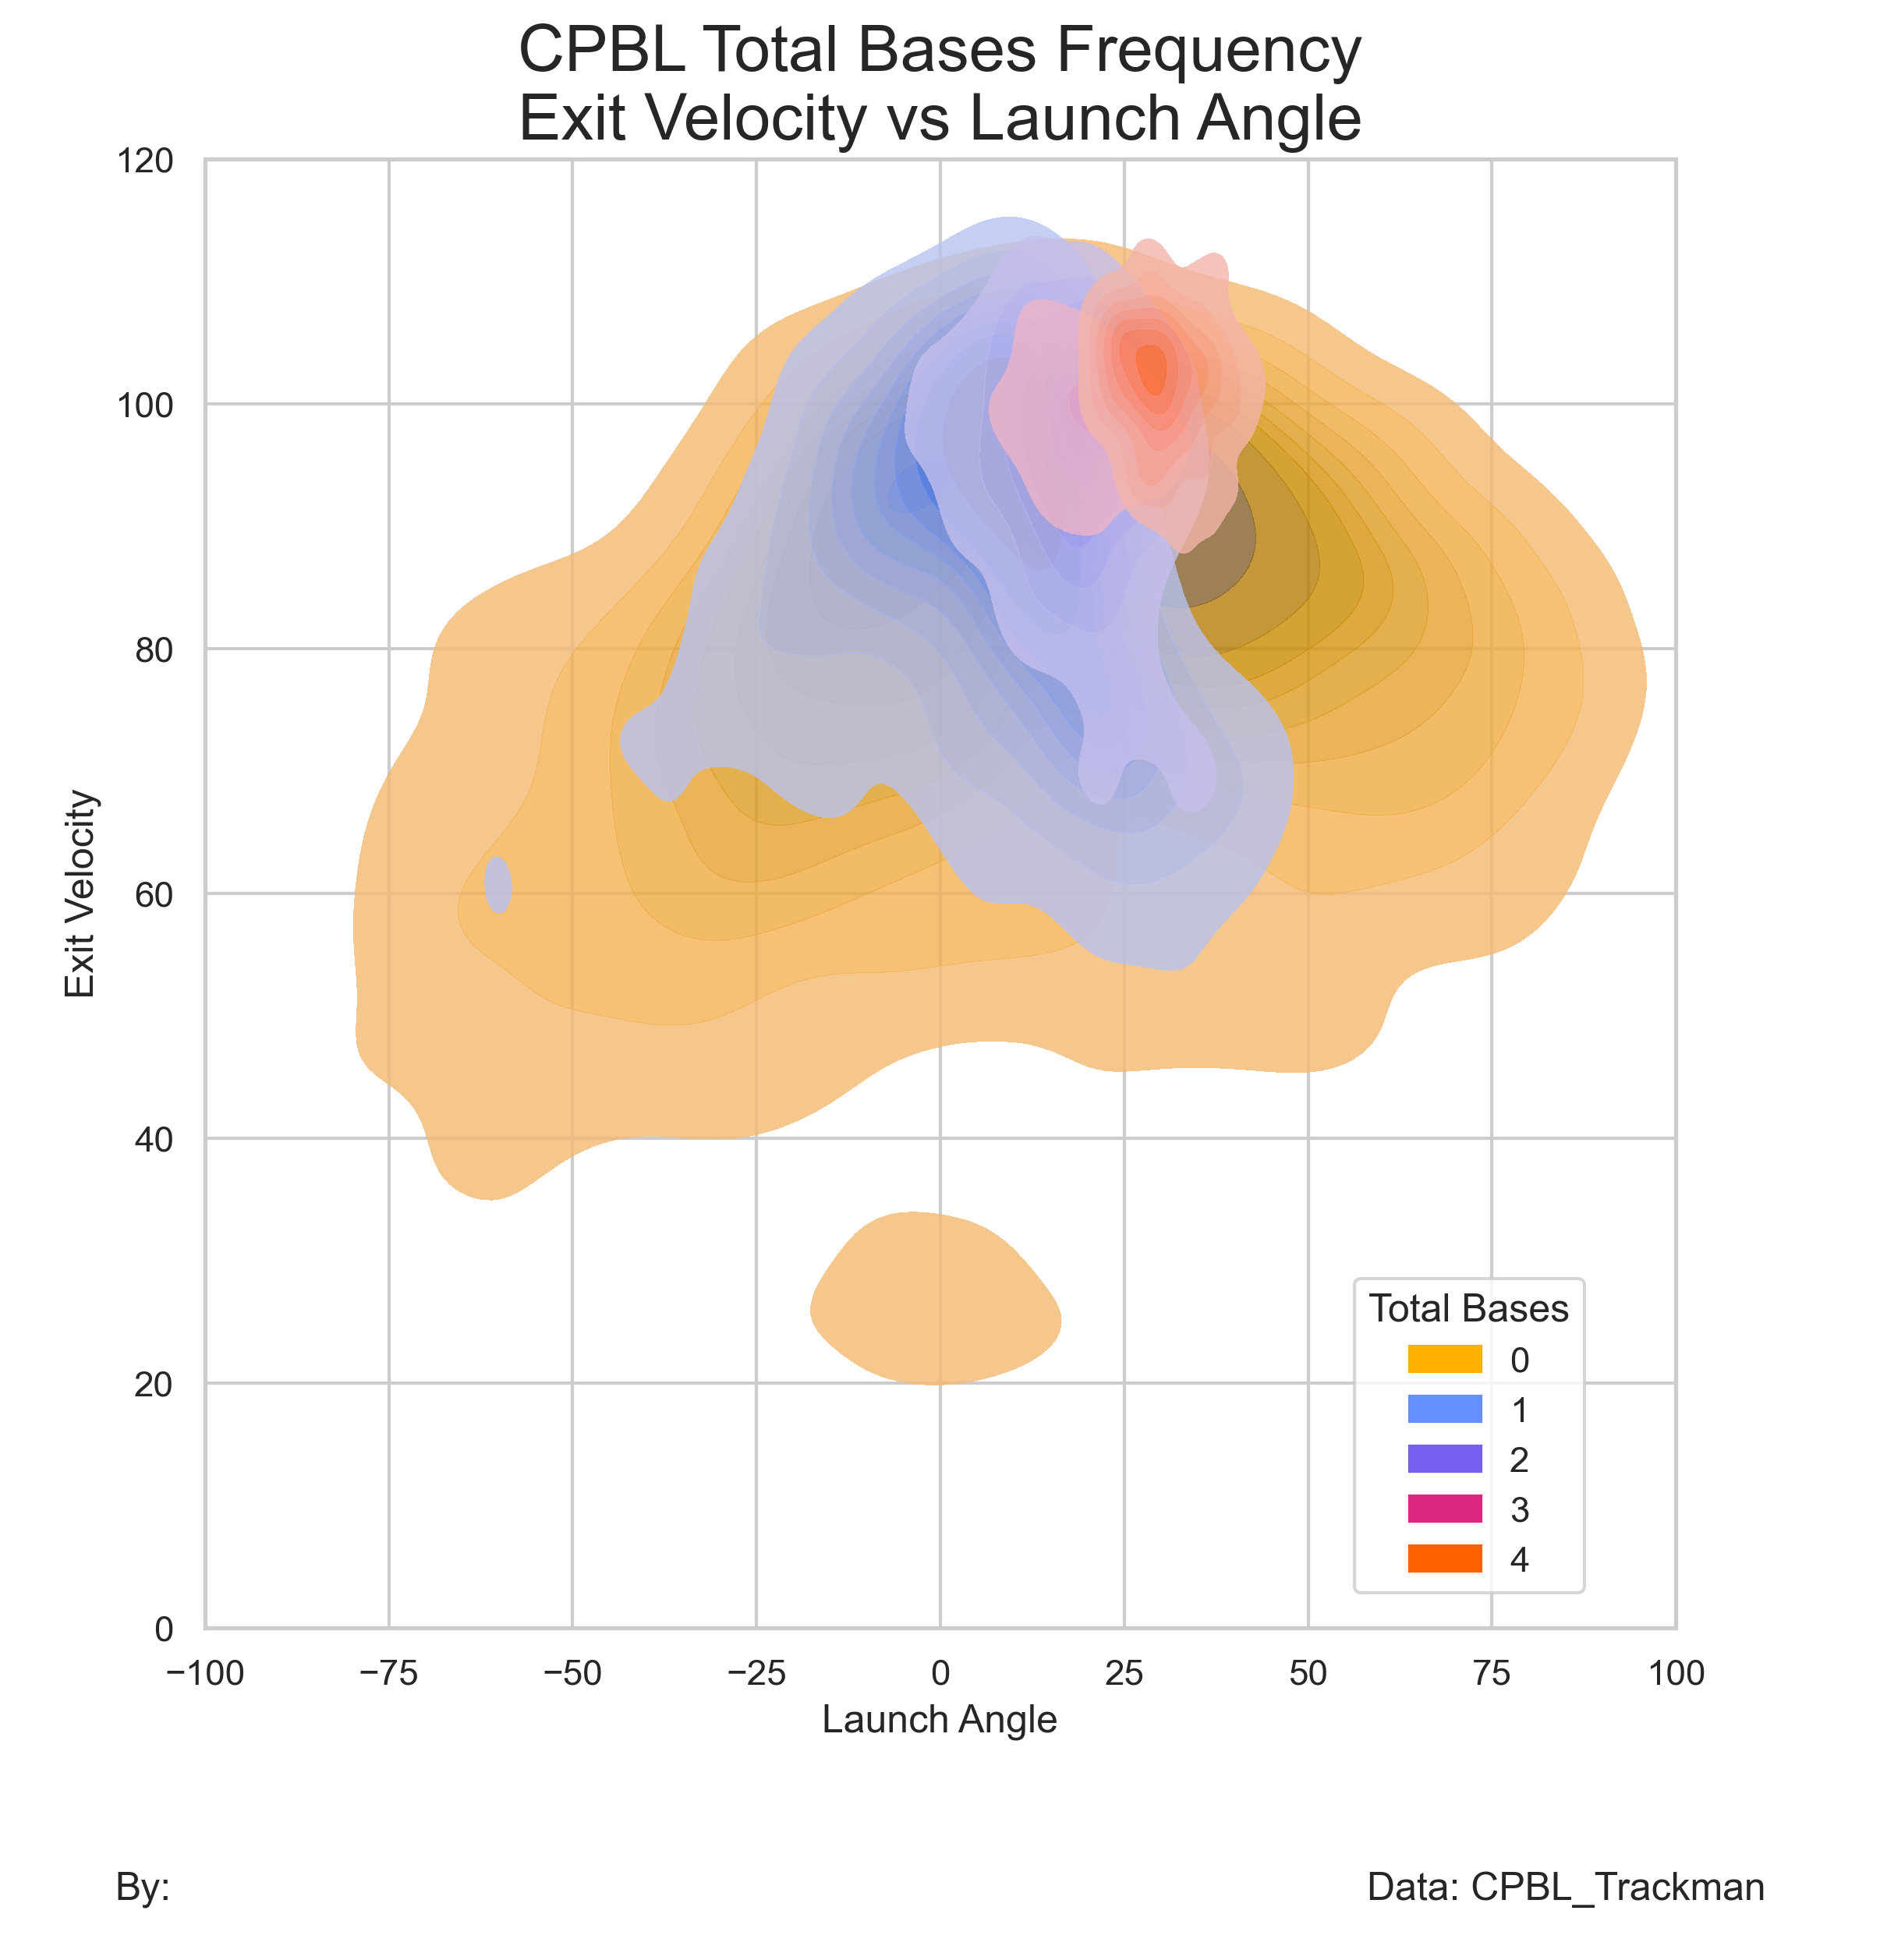

In [32]:
## Initialize plot

sns.set_theme(style="whitegrid", palette=None)
fig = plt.figure(figsize=(8,8),dpi=300)

## Create a grid of subplots to maintain layout
gs = GridSpec(2, 3, height_ratios=[10,1], width_ratios=[0.5,10,0.5])

## Add main subplot and footer subplot
ax = fig.add_subplot(gs[0, 1])
axfooter1 = fig.add_subplot(gs[-1, :])

## Define a custom palette for Total Base outcomes in KDE plot
custom_palette = {0: colour_palette[0], 1: colour_palette[1], 2: colour_palette[2], 3: colour_palette[3], 4: colour_palette[4]}

## Generate KDE plot. Sample 10000 events to avoid extended plotting period
sns.kdeplot(data=data.sample(10000),
             x='Angle',
             y='ExitSpeed',
             hue='tb',ax=ax,
             palette=custom_palette,fill=True,alpha=0.8,legend='Total Bases') 

## Adjust legend and legend title
ax.get_legend().set_title('Total Bases')
ax.get_legend().set_bbox_to_anchor([0.75,0.1,0.2,0.15])

## Add title to plot
ax.set_title('CPBL Total Bases Frequency\nExit Velocity vs Launch Angle',fontsize=20)

## Add axis labels to plot 
ax.set_xlabel('Launch Angle')
ax.set_ylabel('Exit Velocity')

## Adjust x and y-axis bounds
ax.set_ylim(0,120)
ax.set_xlim(-100,100)

## Add footer text 
axfooter1.text(.05, 0.2, "By:",ha='left', va='bottom',fontsize=12)
axfooter1.text(0.95, 0.2, "Data: CPBL_Trackman",ha='right', va='bottom',fontsize=12)
axfooter1.axis('off')


# Adjusting subplot to center it within the figure
fig.subplots_adjust(left=0.01, right=0.99, top=0.975, bottom=0.025)

In [33]:
final_resault = data

In [34]:
playresult_items = final_resault['result'].unique()
playresult_items

array(['GO', 'SO', 'FO', '1B', 'GIDP', 'uBB', 'FC', 'E', '3B', '2B', 'SH',
       'SF', 'HBP', 'HR', 'DP', 'IHR', 'D3S', 'ID', 'IH', 'IBB'],
      dtype=object)

In [35]:
#result_to_remove = ['Walk','HitByPitch']
#final_resault= final_resault[~final_resault['PlayResult'].isin(result_to_remove)]

In [36]:
final_resault = final_resault.dropna()

In [37]:
final_resault.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28220 entries, 0 to 42504
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bName            28220 non-null  object 
 1   bHand            28220 non-null  object 
 2   bTeamId          28220 non-null  object 
 3   Stadium          28220 non-null  object 
 4   PlayResult       28220 non-null  object 
 5   RunsScored       28220 non-null  float64
 6   ExitSpeed        28220 non-null  float64
 7   Angle            28220 non-null  float64
 8   Distance         28220 non-null  float64
 9   GameID           28220 non-null  object 
 10  TaggedHitType    28220 non-null  object 
 11  KorBB            28220 non-null  object 
 12  BatterId         28220 non-null  float64
 13  PitchCall        28220 non-null  object 
 14  TaggedPitchType  28220 non-null  object 
 15  pType            28220 non-null  object 
 16  result           28220 non-null  object 
 17  zone25           

In [38]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# 四.xWOBA 計算

## 特徵篩選

In [39]:
X = final_resault[['ExitSpeed', 'Angle']]
#,'Double','HomeRun','Out','Sacrifice','Single','Triple']]
# 將 y 改為 woba 欄位
y = final_resault[['woba']] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=40)

### KNN (最終使用此模型)

In [40]:
# 2. 建立 Pipeline：先標準化 (StandardScaler) 再跑 KNN
# 對於 2 萬筆數據，嘗試 K=15~30 之間通常效果不錯
model = make_pipeline(
    StandardScaler(), 
    KNeighborsRegressor(n_neighbors=30, weights='distance') # 加入 weights='distance' 讓距離近的樣本權重更高
)

# 3. 訓練模型
model.fit(X_train, y_train)

# 4. 評估
y_pred_test = model.predict(X_test)
print(f"優化後 MSE: {mean_squared_error(y_test, y_pred_test):.4f}")
print(f"優化後 R-squared: {r2_score(y_test, y_pred_test):.4f}")

優化後 MSE: 0.1384
優化後 R-squared: 0.3149


In [41]:
import joblib

# 儲存模型
joblib.dump(model, "woba_model.pkl")
print("模型已儲存！")

模型已儲存！


# 五.整理各球員平均EV,仰角,擊球距離,woba和xwoba

In [42]:
#df_2021 = data[data['Year'] == '2021']
#df_2022 = data[data['Year'] == '2022']
#df_2023 = data[data['Year'] == '2023']
#df_2024 = data[data['Year'] == '2024']
#df1 = pd.concat([df_2021, df_2022], ignore_index=True)
#df2 = pd.concat([df1, df_2023], ignore_index=True)
#df = pd.concat([df2, df_2024], ignore_index=True)
#df_2024 

In [43]:
year_items = data['Year'].unique()
year_items

array(['2026', '2025', '2024', '2023'], dtype=object)

In [44]:
df = data

In [45]:
# 3. 預測（保留所有原始資料列）
features = ['ExitSpeed', 'Angle']
df['woba_pred'] = np.nan

# 建立遮罩：只針對有資料的列預測
valid_mask = df[features].notna().all(axis=1)

if valid_mask.any():
    # 提取有效數據
    X_predict = df.loc[valid_mask, features]
    
    # 預測直接產出 woba 值，不再需要點積運算與權重陣列
    df.loc[valid_mask, 'woba_pred'] = model.predict(X_predict)

# 檢查結果
print(df[['ExitSpeed', 'Angle', 'woba_pred']].head())

   ExitSpeed      Angle  woba_pred
0   71.97452 -32.901406   0.047436
1        NaN        NaN        NaN
2   81.19549  61.632383  -0.001306
3   91.35278 -20.035785   0.047436
4  103.66826   3.319192   0.751284


In [46]:
df

,bName,bHand,bTeamId,Stadium,PlayResult,RunsScored,ExitSpeed,Angle,Distance,GameID,...,時間,Year,日期,bTeam,球場,室內外,球種,tb,woba,woba_pred
0,曾子祐,R,6569a9ddaf62a48d3f94b422,Douliu,Out,0.0,71.97452,-32.901406,6.09594,20260708-Douliu-1,...,20260708,2026,20260708,Hawks,斗六,Outdoor,直球,0,0.047436,0.047436
1,王博玄,L,6569a9ddaf62a48d3f94b422,Douliu,Strikeout,0.0,NaN,NaN,NaN,20260708-Douliu-1,...,20260708,2026,20260708,Hawks,斗六,Outdoor,直球,0,-0.008252,NaN
2,吳念庭,L,6569a9ddaf62a48d3f94b422,Douliu,Out,0.0,81.19549,61.632383,152.99296,20260708-Douliu-1,...,20260708,2026,20260708,Hawks,斗六,Outdoor,直球,0,-0.001306,-0.001306
3,郭天信,L,65630ee95559b6d7a6d5d201,Douliu,Out,0.0,91.35278,-20.035785,7.42763,20260708-Douliu-1,...,20260708,2026,20260708,Dragons,斗六,Outdoor,直球,0,0.047436,0.047436
4,劉基鴻,R,65630ee95559b6d7a6d5d201,Douliu,Single,0.0,103.66826,3.319192,110.59489,20260708-Douliu-1,...,20260708,2026,20260708,Dragons,斗六,Outdoor,直球,1,0.751284,0.751284
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42500,成晉,R,65630eed5559b6d7a6d5d202,Brothers,Sacrifice,1.0,83.88111,44.657549,271.82560,20231021-Brothers-1,...,20231021,2023,20231021,Monkeys,台中,Outdoor,滑球,0,0.187671,0.187671
42501,梁家榮,L,65630eed5559b6d7a6d5d202,Brothers,Out,0.0,76.40598,88.124795,NaN,20231021-Brothers-1,...,20231021,2023,20231021,Monkeys,台中,Outdoor,伸卡球,0,-0.001306,-0.001306
42502,詹子賢,R,65630ee55559b6d7a6d5d200,Brothers,Out,0.0,98.15558,23.893887,375.41479,20231021-Brothers-1,...,20231021,2023,20231021,Brothers,台中,Outdoor,直球,0,-0.001306,0.402348
42503,陳子豪,L,65630ee55559b6d7a6d5d200,Brothers,Strikeout,0.0,NaN,NaN,NaN,20231021-Brothers-1,...,20231021,2023,20231021,Brothers,台中,Outdoor,卡特球,0,-0.008252,NaN


In [47]:
playresult_items = df['result'].unique()
playresult_items

array(['GO', 'SO', 'FO', '1B', 'GIDP', 'uBB', 'FC', 'E', '3B', '2B', 'SH',
       'SF', 'HBP', 'HR', 'DP', 'IHR', 'D3S', 'ID', 'IH', 'IBB'],
      dtype=object)

In [48]:
## Since did not alter the indices, we can assign the predicted xwOBACON to the 2023 dataset 
#df_2023['woba_pred'] = df_bip_2023['woba_pred']

## Assign a value of 0.696 to every walk in the dataset
df.loc[df['result'].isin(['uBB']),'woba_pred'] = 0.603373
df.loc[df['result'].isin(['IBB']),'woba_pred'] = 0.603373

## Assign a value of 0.726 to every hit by pitch in the dataset
df.loc[df['result'].isin(['HBP']),'woba_pred'] = 0.615195

## Assign a value of 0 to every Strikeout in the dataset 
df.loc[df['result'].isin(['D3S','SO']),'woba_pred'] = 0
#df.loc[df['result'].isin(['SF']),'woba'] = 0

## Create a dataframe which is just wOBA events
df_woba = df.dropna(subset=['woba_pred'])

In [49]:
df_woba

,bName,bHand,bTeamId,Stadium,PlayResult,RunsScored,ExitSpeed,Angle,Distance,GameID,...,時間,Year,日期,bTeam,球場,室內外,球種,tb,woba,woba_pred
0,曾子祐,R,6569a9ddaf62a48d3f94b422,Douliu,Out,0.0,71.97452,-32.901406,6.09594,20260708-Douliu-1,...,20260708,2026,20260708,Hawks,斗六,Outdoor,直球,0,0.047436,0.047436
1,王博玄,L,6569a9ddaf62a48d3f94b422,Douliu,Strikeout,0.0,NaN,NaN,NaN,20260708-Douliu-1,...,20260708,2026,20260708,Hawks,斗六,Outdoor,直球,0,-0.008252,0.000000
2,吳念庭,L,6569a9ddaf62a48d3f94b422,Douliu,Out,0.0,81.19549,61.632383,152.99296,20260708-Douliu-1,...,20260708,2026,20260708,Hawks,斗六,Outdoor,直球,0,-0.001306,-0.001306
3,郭天信,L,65630ee95559b6d7a6d5d201,Douliu,Out,0.0,91.35278,-20.035785,7.42763,20260708-Douliu-1,...,20260708,2026,20260708,Dragons,斗六,Outdoor,直球,0,0.047436,0.047436
4,劉基鴻,R,65630ee95559b6d7a6d5d201,Douliu,Single,0.0,103.66826,3.319192,110.59489,20260708-Douliu-1,...,20260708,2026,20260708,Dragons,斗六,Outdoor,直球,1,0.751284,0.751284
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42500,成晉,R,65630eed5559b6d7a6d5d202,Brothers,Sacrifice,1.0,83.88111,44.657549,271.82560,20231021-Brothers-1,...,20231021,2023,20231021,Monkeys,台中,Outdoor,滑球,0,0.187671,0.187671
42501,梁家榮,L,65630eed5559b6d7a6d5d202,Brothers,Out,0.0,76.40598,88.124795,NaN,20231021-Brothers-1,...,20231021,2023,20231021,Monkeys,台中,Outdoor,伸卡球,0,-0.001306,-0.001306
42502,詹子賢,R,65630ee55559b6d7a6d5d200,Brothers,Out,0.0,98.15558,23.893887,375.41479,20231021-Brothers-1,...,20231021,2023,20231021,Brothers,台中,Outdoor,直球,0,-0.001306,0.402348
42503,陳子豪,L,65630ee55559b6d7a6d5d200,Brothers,Strikeout,0.0,NaN,NaN,NaN,20231021-Brothers-1,...,20231021,2023,20231021,Brothers,台中,Outdoor,卡特球,0,-0.008252,0.000000


In [50]:
name_mapping = {
    '1B':'1',
    '2B':'1', 
    '3B':'1', 
    'HR':'1',
    'FO':'1',
    'GO':'1',
    'FC':'1',
    'SF':'1',
    'GIDP':'1',
    'E':'1',
    'SH':'1',
    'DP':'1',
    'uBB':'1',
    'IBB':'1',
    'D3S':'1',
    'SO':'1'
    #'Strikeout':'0',
    }

# 新增一列"球員"，根据"Pitcher"列的值匹配中文名
df_woba ['In_Play'] = df_woba ['result'].map(name_mapping)
df_woba['In_Play'] = df_woba['In_Play'].astype(float)
df_woba

C:\Users\weisz\AppData\Local\Temp\ipykernel_16032\1104569078.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_woba ['In_Play'] = df_woba ['result'].map(name_mapping)
C:\Users\weisz\AppData\Local\Temp\ipykernel_16032\1104569078.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_woba['In_Play'] = df_woba['In_Play'].astype(float)


,bName,bHand,bTeamId,Stadium,PlayResult,RunsScored,ExitSpeed,Angle,Distance,GameID,...,Year,日期,bTeam,球場,室內外,球種,tb,woba,woba_pred,In_Play
0,曾子祐,R,6569a9ddaf62a48d3f94b422,Douliu,Out,0.0,71.97452,-32.901406,6.09594,20260708-Douliu-1,...,2026,20260708,Hawks,斗六,Outdoor,直球,0,0.047436,0.047436,1.0
1,王博玄,L,6569a9ddaf62a48d3f94b422,Douliu,Strikeout,0.0,NaN,NaN,NaN,20260708-Douliu-1,...,2026,20260708,Hawks,斗六,Outdoor,直球,0,-0.008252,0.000000,1.0
2,吳念庭,L,6569a9ddaf62a48d3f94b422,Douliu,Out,0.0,81.19549,61.632383,152.99296,20260708-Douliu-1,...,2026,20260708,Hawks,斗六,Outdoor,直球,0,-0.001306,-0.001306,1.0
3,郭天信,L,65630ee95559b6d7a6d5d201,Douliu,Out,0.0,91.35278,-20.035785,7.42763,20260708-Douliu-1,...,2026,20260708,Dragons,斗六,Outdoor,直球,0,0.047436,0.047436,1.0
4,劉基鴻,R,65630ee95559b6d7a6d5d201,Douliu,Single,0.0,103.66826,3.319192,110.59489,20260708-Douliu-1,...,2026,20260708,Dragons,斗六,Outdoor,直球,1,0.751284,0.751284,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42500,成晉,R,65630eed5559b6d7a6d5d202,Brothers,Sacrifice,1.0,83.88111,44.657549,271.82560,20231021-Brothers-1,...,2023,20231021,Monkeys,台中,Outdoor,滑球,0,0.187671,0.187671,1.0
42501,梁家榮,L,65630eed5559b6d7a6d5d202,Brothers,Out,0.0,76.40598,88.124795,NaN,20231021-Brothers-1,...,2023,20231021,Monkeys,台中,Outdoor,伸卡球,0,-0.001306,-0.001306,1.0
42502,詹子賢,R,65630ee55559b6d7a6d5d200,Brothers,Out,0.0,98.15558,23.893887,375.41479,20231021-Brothers-1,...,2023,20231021,Brothers,台中,Outdoor,直球,0,-0.001306,0.402348,1.0
42503,陳子豪,L,65630ee55559b6d7a6d5d200,Brothers,Strikeout,0.0,NaN,NaN,NaN,20231021-Brothers-1,...,2023,20231021,Brothers,台中,Outdoor,卡特球,0,-0.008252,0.000000,1.0


In [51]:
name_mapping = {
    '1B':'1',
    '2B':'1', 
    '3B':'1', 
    'HR':'1',
    'FO':'1',
    'GO':'1',
    'FC':'1',
    'GIDP':'1',
    'E':'1',
    'SF':'1',
    'DP':'1',
     }

# 新增一列"球員"，根据"Pitcher"列的值匹配中文名
df_woba ['Hit_In_play'] = df_woba ['result'].map(name_mapping)
df_woba['Hit_In_play'] = df_woba['Hit_In_play'].astype(float)

C:\Users\weisz\AppData\Local\Temp\ipykernel_16032\503006052.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_woba ['Hit_In_play'] = df_woba ['result'].map(name_mapping)
C:\Users\weisz\AppData\Local\Temp\ipykernel_16032\503006052.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_woba['Hit_In_play'] = df_woba['Hit_In_play'].astype(float)


In [52]:
#player_items = df_woba['Batter'].unique()
#player_items

In [53]:
target_year = ['2023','2024','2025','2026']

fillter_woba = (
    df_woba[
        (df_woba['Year'].isin(target_year)) 
    ]
)

In [54]:
fillter_woba 

,bName,bHand,bTeamId,Stadium,PlayResult,RunsScored,ExitSpeed,Angle,Distance,GameID,...,日期,bTeam,球場,室內外,球種,tb,woba,woba_pred,In_Play,Hit_In_play
0,曾子祐,R,6569a9ddaf62a48d3f94b422,Douliu,Out,0.0,71.97452,-32.901406,6.09594,20260708-Douliu-1,...,20260708,Hawks,斗六,Outdoor,直球,0,0.047436,0.047436,1.0,1.0
1,王博玄,L,6569a9ddaf62a48d3f94b422,Douliu,Strikeout,0.0,NaN,NaN,NaN,20260708-Douliu-1,...,20260708,Hawks,斗六,Outdoor,直球,0,-0.008252,0.000000,1.0,NaN
2,吳念庭,L,6569a9ddaf62a48d3f94b422,Douliu,Out,0.0,81.19549,61.632383,152.99296,20260708-Douliu-1,...,20260708,Hawks,斗六,Outdoor,直球,0,-0.001306,-0.001306,1.0,1.0
3,郭天信,L,65630ee95559b6d7a6d5d201,Douliu,Out,0.0,91.35278,-20.035785,7.42763,20260708-Douliu-1,...,20260708,Dragons,斗六,Outdoor,直球,0,0.047436,0.047436,1.0,1.0
4,劉基鴻,R,65630ee95559b6d7a6d5d201,Douliu,Single,0.0,103.66826,3.319192,110.59489,20260708-Douliu-1,...,20260708,Dragons,斗六,Outdoor,直球,1,0.751284,0.751284,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42500,成晉,R,65630eed5559b6d7a6d5d202,Brothers,Sacrifice,1.0,83.88111,44.657549,271.82560,20231021-Brothers-1,...,20231021,Monkeys,台中,Outdoor,滑球,0,0.187671,0.187671,1.0,1.0
42501,梁家榮,L,65630eed5559b6d7a6d5d202,Brothers,Out,0.0,76.40598,88.124795,NaN,20231021-Brothers-1,...,20231021,Monkeys,台中,Outdoor,伸卡球,0,-0.001306,-0.001306,1.0,1.0
42502,詹子賢,R,65630ee55559b6d7a6d5d200,Brothers,Out,0.0,98.15558,23.893887,375.41479,20231021-Brothers-1,...,20231021,Brothers,台中,Outdoor,直球,0,-0.001306,0.402348,1.0,1.0
42503,陳子豪,L,65630ee55559b6d7a6d5d200,Brothers,Strikeout,0.0,NaN,NaN,NaN,20231021-Brothers-1,...,20231021,Brothers,台中,Outdoor,卡特球,0,-0.008252,0.000000,1.0,NaN


In [55]:
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

# 1. 篩選資料 (維持不變)
plot_data = fillter_woba.dropna(subset=['ExitSpeed', 'Angle', 'woba_pred'])

# 2. 建立主圖表 (基本維持不變，僅微調)
fig = px.scatter(
    plot_data, 
    x='ExitSpeed', 
    y='Angle', 
    color='woba_pred',
    hover_data=['bName', 'result', 'woba_pred'],
    color_continuous_scale='RdYlBu_r', 
    labels={'ExitSpeed': 'Exit Velocity (mph)', 
            'Angle': 'Launch Angle (deg)', 
            'woba_pred': 'xwOBA'},
    title='Exit Velocity & Launch Angle vs. xWOBA with Precise Barrel Zone',
    opacity=0.6
)

# 3. 定義精確的 Barrel Zone 多邊形頂點
# 這些點是根據 Statcast 定義和圖中趨勢推算的臨界點
# 結構為：[(x1, y1), (x2, y2), ..., (xN, yN)]
barrel_path = [
    (98, 26),    # 98 mph 的仰角下限
    (98, 30),    # 98 mph 的仰角上限
    (110, 42),   # 110 mph 時上限擴展
    (116, 50),   # 116+ mph 時的上限臨界點
    (125, 50),   # 設定一個圖表最大初速上限 (以圖表最大值為準)
    (125, 8),    # 設定一個圖表最大初速下限
    (116, 8),    # 116+ mph 時的下限臨界點
    (110, 16),   # 110 mph 時下限收縮
    (98, 26)     # 回到起點封閉多邊形
]

# 將頂點解構為 X 和 Y 的列表
barrel_x, barrel_y = zip(*barrel_path)

# 4. 優化圖表佈局與新增 Barrel 區域 (使用 go.Scatter 繪製填充多邊形)
fig.update_layout(
    height=800,  # 加長圖表
    template='plotly_white'
)

fig.add_hline(y=0, line_dash="dash", line_color="gray") 

# 使用 go.Scatter 增加一個填充層
fig.add_trace(go.Scatter(
    x=barrel_x,
    y=barrel_y,
    fill='toself',                  # 填充多邊形內部
    fillcolor='rgba(0, 0, 0, 0.08)',# 極淡的半透明灰色，避免遮擋數據點
    line=dict(color='black', width=1.5, dash='dash'), # 黑色虛線邊框
    name='Precise Barrel Zone',
    showlegend=True,
    hoverinfo='skip'                # 滑鼠移過去不顯示此圖層的資訊
))

# 確保數據點層在填充層上方 (如果有需要調整層次)
# fig.data = fig.data[::-1] 

# 5. 顯示圖表
fig.show()

## 計算單人平均

In [56]:
# 1. 定義分子要加總的項目 (wOBA weights)
numerator_results = ['uBB', 'HBP', '1B', '2B', '3B', 'HR']
Woba_scale = 1.2269079390079072

# 2. 定義不計入分母的項目 (通常 wOBA 會排除 IBB)
# 如果你的 PA 本身就不含 IBB，這步可省略
#exclude_from_pa = ['IBB']

# 3. 處理數據
# 只有在 numerator_results 裡的才保留權重，其餘（如 SO, FO, GO）權重設為 0
fillter_woba['woba_value'] = np.where(
    fillter_woba['result'].isin(numerator_results), 
    fillter_woba['woba'], 
    0
)

# 4. 進行分組計算
df_output = fillter_woba.groupby(['bName','bTeam', 'Year']).apply(lambda x: pd.Series({
    'woba_pa': x['In_Play'].sum(),
    'woba': (x['woba_value'].sum() * Woba_scale / x['In_Play'].sum()) if x['In_Play'].sum() > 0 else 0,
    'xwoba': x['woba_pred'].mean() * Woba_scale
})).reset_index()

df_output2 = fillter_woba[fillter_woba['Hit_In_play'] == 1].groupby(['bName','bTeam','Year']).agg(
    EV = ('ExitSpeed','mean'),
    Angle = ('Angle','mean'),
    Distance = ('Distance','mean')
).reset_index()

merged_df = df_output.merge(df_output2, on=['bName','bTeam','Year'])
merged_df['EV(KM)'] = merged_df['EV']*1.609
merged_df['woba_diff']=merged_df['xwoba']-merged_df['woba']
merged_df.reset_index(drop=False, inplace=True)
merged_df

C:\Users\weisz\AppData\Local\Temp\ipykernel_16032\2575646611.py:18: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,index,bName,bTeam,Year,woba_pa,woba,xwoba,EV,Angle,Distance,EV(KM),woba_diff
0,0,何品室融,Monkeys,2025,4.0,0.000000,0.036078,80.255098,27.744453,99.725227,129.130452,0.036078
1,1,何品室融,Monkeys,2026,133.0,0.285312,0.290371,84.100715,4.101933,156.322112,135.318051,0.005059
2,2,何恆佑,Lions,2023,12.0,0.189001,0.125557,87.299487,13.740787,165.293991,140.464874,-0.063444
3,3,何恆佑,Lions,2024,11.0,0.206183,0.109218,86.713812,12.735039,223.453606,139.522524,-0.096965
4,4,何恆佑,Lions,2026,20.0,0.092176,0.136247,90.336656,-2.253749,121.087175,145.351679,0.044072
...,...,...,...,...,...,...,...,...,...,...,...,...
591,591,黃鈞聲,Brothers,2024,2.0,0.000000,-0.001602,88.959080,33.463864,267.755380,143.135160,-0.001602
592,592,黃鈞麟,Brothers,2025,4.0,0.185071,0.231576,72.152875,-16.974378,90.050105,116.093976,0.046505
593,593,黃韋盛,Brothers,2023,43.0,0.177141,0.210421,85.754221,1.104612,120.361033,137.978542,0.033280
594,594,黃韋盛,Brothers,2025,237.0,0.284792,0.312873,85.004540,3.409069,134.488400,136.772305,0.028081


#### 匯出檔案

In [57]:
merged_df.to_excel('2026_Player_xWOBA.xlsx', index=True)

## 計算團隊平均

In [58]:
# 1. 定義分子要加總的項目 (wOBA weights)
numerator_results = ['uBB', 'HBP', '1B', '2B', '3B', 'HR']
#Woba_scale = 1.2269079390079072

# 2. 定義不計入分母的項目 (通常 wOBA 會排除 IBB)
# 如果你的 PA 本身就不含 IBB，這步可省略
#exclude_from_pa = ['IBB']

# 3. 處理數據
# 只有在 numerator_results 裡的才保留權重，其餘（如 SO, FO, GO）權重設為 0
fillter_woba['woba_value'] = np.where(
    fillter_woba['result'].isin(numerator_results), 
    fillter_woba['woba'], 
    0
)

# 4. 進行分組計算
df_output = fillter_woba.groupby(['bTeam', 'Year']).apply(lambda x: pd.Series({
    'woba_pa': x['In_Play'].sum(),
    'woba': x['woba_value'].sum()*Woba_scale / x['In_Play'].sum() if x['In_Play'].sum() > 0 else 0,
    'xwoba': x['woba_pred'].mean()*Woba_scale
})).reset_index()

df_output2 = fillter_woba[fillter_woba['Hit_In_play'] == 1].groupby(['bTeam','Year']).agg(
    EV = ('ExitSpeed','mean'),
    Angle = ('Angle','mean'),
    Distance = ('Distance','mean')
).reset_index()

merged_df = df_output.merge(df_output2, on=['bTeam','Year'])
merged_df['EV(KM)'] = merged_df['EV']*1.609
merged_df['woba_diff']=merged_df['xwoba']-merged_df['woba']
merged_df.reset_index(drop=False, inplace=True)
merged_df

C:\Users\weisz\AppData\Local\Temp\ipykernel_16032\2507156474.py:18: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,index,bTeam,Year,woba_pa,woba,xwoba,EV,Angle,Distance,EV(KM),woba_diff
0,0,Brothers,2023,2376.0,0.327671,0.321533,83.237987,10.958809,161.006690,133.929921,-0.006138
1,1,Brothers,2024,1844.0,0.361734,0.369373,87.000364,16.750267,189.762331,139.983586,0.007639
2,2,Brothers,2025,3101.0,0.323704,0.333107,85.621317,10.468085,159.225104,137.764698,0.009403
3,3,Brothers,2026,2287.0,0.318422,0.321453,86.040000,11.524168,158.916146,138.438360,0.003032
4,4,Dragons,2023,1458.0,0.336534,0.327781,82.470842,11.163349,156.487171,132.695585,-0.008753
5,5,Dragons,2024,1805.0,0.331334,0.335894,84.646237,14.679954,177.721213,136.195795,0.004560
6,6,Dragons,2025,3410.0,0.331029,0.336114,84.650561,11.540747,160.211162,136.202753,0.005085
7,7,Dragons,2026,2191.0,0.323761,0.328383,85.495823,12.436417,157.433367,137.562780,0.004622
8,8,Guardians,2023,675.0,0.327195,0.319048,82.135252,14.881810,166.889918,132.155620,-0.008147
9,9,Guardians,2024,594.0,0.331971,0.318844,84.704016,13.453489,168.801702,136.288762,-0.013126


In [59]:
merged_df.to_excel('2026_Team_xWOBA.xlsx', index=True)

In [60]:
start_date = 20260703
end_date = 20260709

# 篩選日期 20260428 ~ 20260503
fillter_woba['日期_int'] = fillter_woba['日期'].astype(int)
fillter_woba2 = fillter_woba[
    (fillter_woba['日期_int'] >= start_date) & 
    (fillter_woba['日期_int'] <= end_date)  
    #(fillter_woba['bTeam'] == '兄弟')
]

# 1. 定義分子要加總的項目
numerator_results = ['uBB', 'HBP', '1B', '2B', '3B', 'HR']
#Woba_scale = 1.2269079390079072

# 3. 處理數據
fillter_woba2['woba_value'] = np.where(
    fillter_woba2['result'].isin(numerator_results),
    fillter_woba2['woba'],
    0
)

# 4. 進行分組計算
df_output = fillter_woba2.groupby(['bName','bTeam', 'Year']).apply(lambda x: pd.Series({
    'woba_pa': x['In_Play'].sum(),
    'woba': (x['woba_value'].sum() * Woba_scale / x['In_Play'].sum()) if x['In_Play'].sum() > 0 else 0,
    'xwoba': x['woba_pred'].mean() * Woba_scale
})).reset_index()

# 修改 df_output2 的邏輯，避免 In_Play 變成索引的一部分導致 merge 困難
# 這裡過濾 In_Play == 1 的擊球數據來計算平均值
df_output2 = fillter_woba2[fillter_woba2['Hit_In_play'] == 1].groupby(['bName','bTeam','Year']).agg(
    EV = ('ExitSpeed','mean'),
    Angle = ('Angle','mean'),
    Distance = ('Distance','mean')
).reset_index()

# 合併數據
merged_df = df_output.merge(df_output2, on=['bName','bTeam','Year'], how='left')
merged_df['EV(KM)'] = merged_df['EV'] * 1.609
merged_df['woba_diff'] = merged_df['xwoba'] - merged_df['woba']

# 格式化輸出
merged_df = merged_df.round(3)
merged_df.rename(columns={
    'bName': 'bName',
    'bTeam': 'bTeam',
    'Year': 'Year',
    'woba_pa': 'PA',
    'EV': 'AVG_EV',
    'Angle': 'AVG_LA',
    'Distance': 'AVG_Distance'
}, inplace=True)

# 儲存 Excel
merged_df

C:\Users\weisz\AppData\Local\Temp\ipykernel_16032\3689723633.py:17: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\weisz\AppData\Local\Temp\ipykernel_16032\3689723633.py:24: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,bName,bTeam,Year,PA,woba,xwoba,AVG_EV,AVG_LA,AVG_Distance,EV(KM),woba_diff
0,何品室融,Monkeys,2026,2.0,0.377,0.271,63.471,-5.595,15.744,102.125,-0.106
1,劉俊緯,Dragons,2026,12.0,0.431,0.480,79.297,10.106,160.801,127.589,0.050
2,劉俊豪,Guardians,2026,5.0,0.332,0.199,85.884,14.952,136.574,138.188,-0.133
3,劉基鴻,Dragons,2026,16.0,0.419,0.390,87.391,18.361,140.399,140.612,-0.030
4,劉子杰,Monkeys,2026,15.0,0.172,0.268,86.013,4.030,151.204,138.395,0.096
...,...,...,...,...,...,...,...,...,...,...,...
90,高宇杰,Brothers,2026,12.0,0.419,0.336,85.013,22.597,181.750,136.786,-0.083
91,高聖恩,Hawks,2026,6.0,0.307,0.307,81.496,12.676,178.422,131.127,-0.000
92,魔鷹,Hawks,2026,16.0,0.208,0.191,101.715,13.146,144.215,163.659,-0.017
93,黃劼希,Hawks,2026,6.0,0.277,0.286,78.415,-14.328,118.339,126.169,0.009


In [61]:
# 修改儲存檔名，加入日期區間
file_name = f'Player_xWOBA_{start_date}_{end_date}.xlsx'

# 儲存 Excel
merged_df.to_excel(file_name, index=True)

In [62]:
# 1. 定義分子要加總的項目
numerator_results = ['uBB', 'HBP', '1B', '2B', '3B', 'HR']

# 1. 定義目標區域
target_zones = [7, 8, 9, 12, 13, 14, 17, 18, 19]

# 2. 篩選指定 zone25 的數據 (直接在計算前過濾)
fillter_woba_zone = fillter_woba2[fillter_woba2['zone25'].isin(target_zones)].copy()

# 3. 處理數據 (使用過濾後的 fillter_woba_zone)
fillter_woba_zone['woba_value'] = np.where(
    fillter_woba_zone['result'].isin(numerator_results),
    fillter_woba_zone['woba'],
    0
)

# 4. 進行分組計算 (woba 部分)
df_output = fillter_woba_zone.groupby(['bName','bTeam', 'Year']).apply(lambda x: pd.Series({
    'woba_pa': x['In_Play'].sum(),
    'woba': (x['woba_value'].sum() * Woba_scale / x['In_Play'].sum()) if x['In_Play'].sum() > 0 else 0,
    'xwoba': x['woba_pred'].mean() * Woba_scale
})).reset_index()

# 5. 處理擊球數據 (同樣使用過濾後的 fillter_woba_zone)
df_output2 = fillter_woba_zone[fillter_woba_zone['Hit_In_play'] == 1].groupby(['bName','bTeam','Year']).agg(
    EV = ('ExitSpeed','mean'),
    Angle = ('Angle','mean'),
    Distance = ('Distance','mean')
).reset_index()

# 6. 合併與後續處理
merged_df = df_output.merge(df_output2, on=['bName','bTeam','Year'], how='left')
merged_df['EV(KM)'] = merged_df['EV'] * 1.609
merged_df['woba_diff'] = merged_df['xwoba'] - merged_df['woba']

# 7. 格式化輸出
merged_df = merged_df.round(3)
merged_df.rename(columns={
    'woba_pa': 'PA',
    'EV': 'AVG_EV',
    'Angle': 'AVG_LA',
    'Distance': 'AVG_Distance'
}, inplace=True)

# 儲存 Excel
merged_df

C:\Users\weisz\AppData\Local\Temp\ipykernel_16032\991921925.py:18: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,bName,bTeam,Year,PA,woba,xwoba,AVG_EV,AVG_LA,AVG_Distance,EV(KM),woba_diff
0,何品室融,Monkeys,2026,1.0,0.000,0.000,NaN,NaN,NaN,NaN,0.000
1,劉俊緯,Dragons,2026,8.0,0.461,0.528,81.536,10.099,169.420,131.191,0.067
2,劉俊豪,Guardians,2026,2.0,0.461,0.462,85.813,19.584,8.060,138.074,0.001
3,劉基鴻,Dragons,2026,9.0,0.512,0.474,88.867,22.895,166.796,142.986,-0.038
4,劉子杰,Monkeys,2026,8.0,0.230,0.365,83.234,0.534,130.184,133.924,0.135
...,...,...,...,...,...,...,...,...,...,...,...
83,高宇杰,Brothers,2026,8.0,0.399,0.310,84.029,23.557,154.817,135.203,-0.089
84,高聖恩,Hawks,2026,5.0,0.369,0.368,81.496,12.676,178.422,131.127,-0.000
85,魔鷹,Hawks,2026,5.0,0.184,0.197,104.824,21.476,133.040,168.662,0.012
86,黃劼希,Hawks,2026,2.0,0.461,0.490,77.116,-31.721,58.902,124.080,0.029


In [63]:
# 修改儲存檔名，加入日期區間
file_name = f'Player_xWOBA_inZone_{start_date}_{end_date}.xlsx'

# 儲存 Excel
merged_df.to_excel(file_name, index=True)